<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Sesiones/Sesion_03_intuicion_estadistica_II_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Intución estadística 2D

In [ ]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from scipy import optimize
from scipy.stats import norm
from matplotlib import cm
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split
#Machinig learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ShuffleSplit

In [ ]:
# @title Libs codes: Meshgrid and learning curves
def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_contoursExact(ax, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(
        fit_times_mean,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

# Repaso:
# 2 Dimensiones

### Caso Bivariante



Una función de densidad conjunta es una función que describe la probabilidad de que dos o más variables aleatorias tomen ciertos valores simultáneamente,
para el caso bivariante es:

\begin{equation}
f(x, y) = \frac{1}{2\pi \sigma_x \sigma_y \sqrt{1-\rho^2}} \exp \left( -\frac{1}{2(1-\rho^2)} \left(\frac{x^2}{\sigma_x^2} + \frac{y^2}{\sigma_y^2} - \frac{2\rho xy}{\sigma_x \sigma_y} \right) \right)
\end{equation}

Donde:

- $\rho$ es el coeficiente de correlación.
- Las medias de las variables son $(0, 0)$.

La matriz de covarianzas está dada por:

\begin{equation}
\Sigma =  
\begin{bmatrix}
\sigma_x^2 & \rho \sigma_x \sigma_y  \\
\rho \sigma_x \sigma_y & \sigma_y^2
\end{bmatrix}
\end{equation}


La anterior funcion cumple que:


\begin{equation}
\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y)\mathrm{dx}\mathrm{dy} = 1
\end{equation}



### En el caso caso mas general

Para el caso más general, la función de densidad conjunta para una distribución normal multivariante se expresa como:

\begin{equation}
f_X(x_1,x_2, ... x_n) = \frac{1}{2\pi^{n/2}|\Sigma|^{1/2}} \exp\left( -\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)\right)
\end{equation}

Donde $|\Sigma|$ es el determinante de la matriz de covarianza $\Sigma$.


Veamos un ejemplo para valor de $\mu$ y $\Sigma$, dados de la siguiente forma:

\begin{equation}
\mu =  
\begin{bmatrix}
0 \\
0 \\
\end{bmatrix}
\end{equation}

\begin{equation}
\Sigma =  
\begin{bmatrix}
1 & 0  \\
0 & 1\\
\end{bmatrix}
\end{equation}


\begin{equation}
\Sigma =  
\begin{bmatrix}
1 & 0.5  \\
0.5 & 1\\
\end{bmatrix}
\end{equation}


\begin{equation}
\Sigma =  
\begin{bmatrix}
1 & 0.8  \\
0.8 & 1\\
\end{bmatrix}
\end{equation}


Text(0, 0.5, '$PDF(X_1, X_2)$')

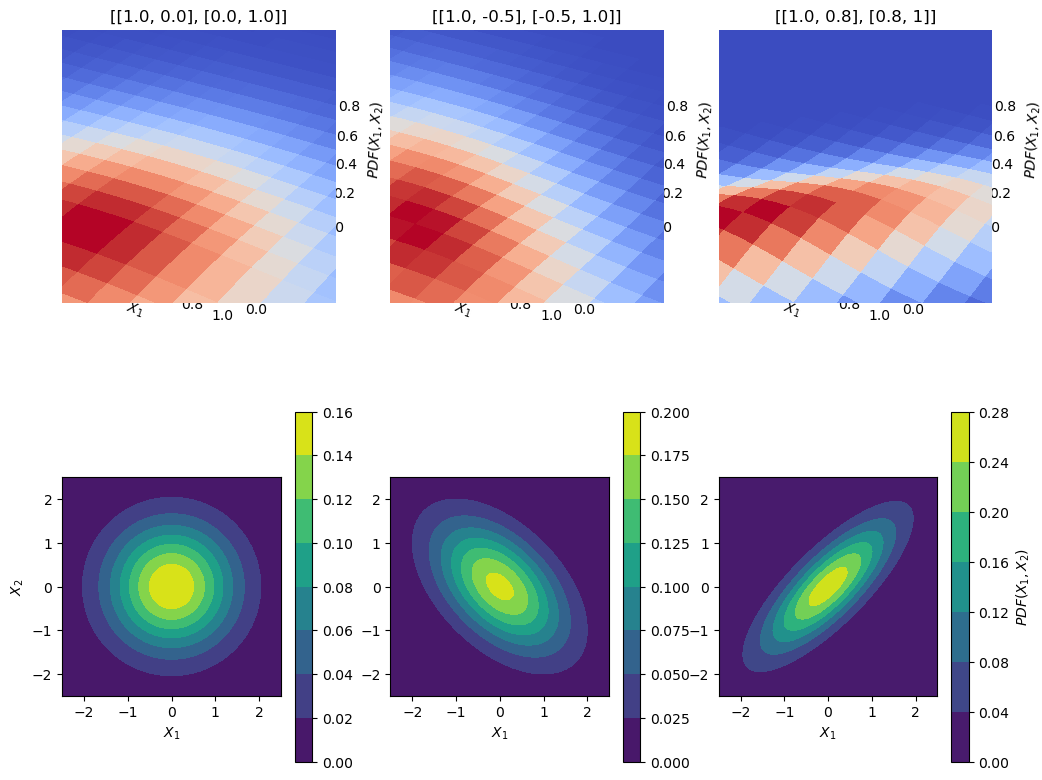

In [ ]:
# @title Funcion de distribucion de probabilidad

x, y = np.mgrid[-4:4:.1, -4:4:.1]
pos = np.dstack((x, y))
mu = [0.0, 0.0]                 # Centrada en el origen
cov = [[1.0, 0.0], [0.0, 1.0]]  # Matriz de covarianzas identidad
rv = multivariate_normal(mu, cov)

x1, y1 = np.mgrid[-4:4:.1, -4:4:.1]
pos1 = np.dstack((x1, y1))
mu1 = [0.0, 0.0]                 # Centrada en el origen
cov1 = [[1.0, -0.5], [-0.5, 1.0]]  # Matriz de covarianzas identidad
rv1 = multivariate_normal(mu1, cov1)

x2, y2 = np.mgrid[-4:4:.1, -4:4:.1]
pos2 = np.dstack((x2, y2))
mu2 = [0.0, 0.0]                 # Centrada en el origen
cov2 = [[1.0, 0.8], [0.8, 1]]  # Matriz de covarianzas identidad
rv2 = multivariate_normal(mu2, cov2)


# Set up a figure twice as tall as it is wide
fig = plt.figure(figsize = (12,10))

ax = fig.add_subplot(2, 3, 1, projection='3d')
ax.set_aspect('equal')
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(x,y, rv.pdf(pos), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")
ax.set_title(f"{cov}")

ax = fig.add_subplot(2, 3, 2, projection='3d')
ax.set_aspect('equal')
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(x1,y1, rv1.pdf(pos1), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")
ax.set_title(f"{cov1}")

ax = fig.add_subplot(2, 3, 3, projection='3d')
ax.set_aspect('equal')
#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(x2,y2, rv2.pdf(pos2), cmap = cm.coolwarm,
                       linewidth = 0, antialiased = False)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$PDF(X_1,X_2)$")
ax.set_title(f"{cov2}")

#=============================================================
ax = fig.add_subplot(2, 3, 4)
cs = ax.contourf(x, y, rv.pdf(pos))
ax.set_aspect('equal')
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs)
#cbar.ax.set_ylabel('PDF(X_1, X_2)$')

ax = fig.add_subplot(2, 3, 5)
cs = ax.contourf(x1, y1, rv1.pdf(pos1))
ax.set_aspect('equal')
ax.set_xlabel("$X_1$")
#ax.set_ylabel("$X_2$")
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs)
#cbar.ax.set_ylabel('PDF(X_1, X_2)$')

ax = fig.add_subplot(2, 3, 6)
ax.set_aspect('equal')
cs = ax.contourf(x2, y2, rv2.pdf(pos2))
ax.set_xlabel("$X_1$")
#ax.set_ylabel("$X_2$")
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
cbar = fig.colorbar(cs)
cbar.ax.set_ylabel('$PDF(X_1, X_2)$')
#=============================================================


# Dado el siguiente dataset:

|m         |Y  (Var. indep)       | $X_1$ (feature 1)      |$X_2$     (feature2)  |
| --------|-----------|-------------|-----------|
|1        |$Y^{(1)}$  | $X_1^{(1)}$ |  $X_2^{(1)}$|
|2        |$Y^{(2)}$  | $X_1^{(2)}$ | $X_2^{(2)}$|
| ...        |...          | ...           |...          |
|...        |...          | ...           |...          |
|...      |...         | ...           |...         |
|m        |$Y^{(m)}$ | $X_1^{(m)}$  |$X_2^{(m)}$|



In [ ]:
def data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   ):# Caso mas visible
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1

def sample(N1= 1000, N2 = 100, r = 0.2):
  X_t = np.concatenate([rv.rvs(N1, random_state = r  ), rv1.rvs(N2,random_state = r)]) # Todos los datos en la misma distribución,
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y


In [ ]:
def graph_gaussian_contour(x, y, pos, rv,  rv2):
  fig = plt.figure(figsize = (12,6))
  ax = fig.add_subplot(1, 2, 1, projection='3d')
  surf1 = ax.plot_surface(x,y, rv.pdf(pos) + rv1.pdf(pos), cmap = cm.coolwarm,
                        linewidth = 0, antialiased = False)
  ax.set_xlabel("$X_1$")
  ax.set_ylabel("$X_2$")
  ax.set_zlabel("$PDF(X_1,X_2)$")
  #=============================================================
  ax = fig.add_subplot(1, 2, 2)
  cs1 = ax.contourf(x, y, rv.pdf(pos) + rv1.pdf(pos)  )
  #cs2 = ax.contourf(x1, y1, rv1.pdf(pos1) )
  ax.set_xlabel("$X_1$")
  ax.set_ylabel("$X_2$")
  #ax.set_xlim(-2.5,2.5)
  #ax.set_ylim(-2.5,2.5)
  cbar = fig.colorbar(cs1)
# Histograma de los datos sinteticos a estudiar


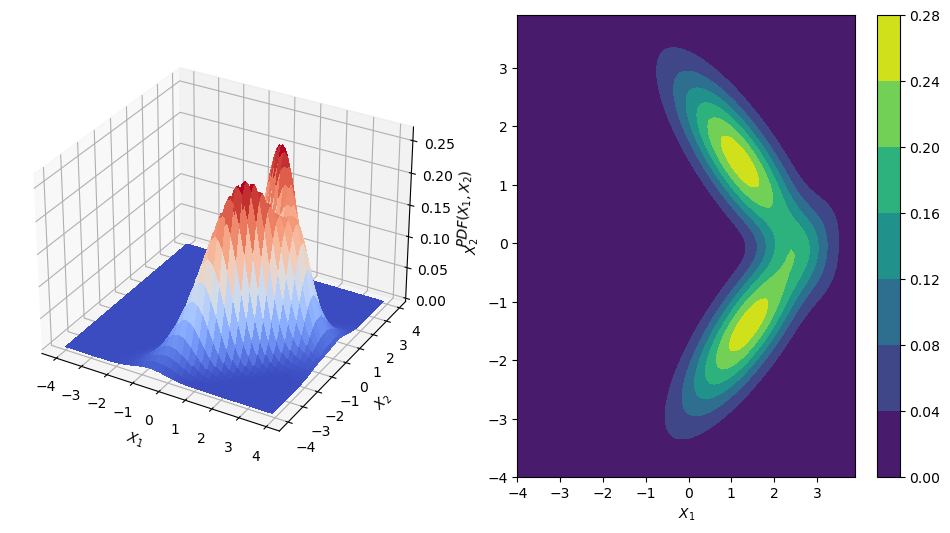

In [ ]:
rv, rv1 = data( mu=[1.2,1.4], mu1=[1.4,-1.4],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
#Mesh para la grafica en 3D
x, y = np.mgrid[-4:4:.1, -4:4:.1]
pos = np.dstack((x, y))
graph_gaussian_contour(x, y, pos, rv, rv1)

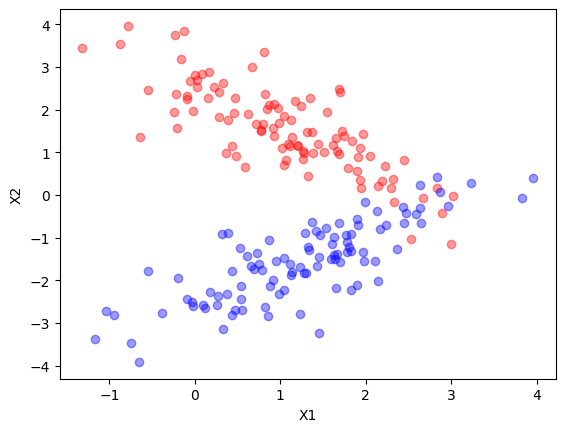

In [ ]:
rv, rv1 = data( mu=[1.2,1.4], mu1=[1.4,-1.4],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 100, N2 = 100, r = 10)

plt.plot(X_t[y==0][:,0],X_t[y==0][:,1],"ro", alpha=0.4)
plt.plot(X_t[y==1][:,0],X_t[y==1][:,1],"bo", alpha=0.4)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [ ]:
from pydub import AudioSegment
from pydub.generators import Sine
import numpy as np
import pandas as pd

# Definir una escala musical (notas en Hz) para hacer el sonido más armónico
scale_class_0 = [261.63]#, 293.66, 329.63, 349.23, 392.00, 440.00, 493.88]  # Clase 0: tonos graves
scale_class_1 = [987.77]#, 587.33, 659.25, 698.46, 783.99, 880.00, 987.77]  # Clase 1: tonos agudos

# Función para generar sonido basado en la clase Y, usando notas musicales
def generate_harmonic_sound(X1, Y, duration=500):
    # Seleccionar la escala según la clase
    if Y == 0:
        scale = scale_class_0  # Tonos graves
    else:
        scale = scale_class_1  # Tonos agudos

    # Normalizar X1 para seleccionar una nota de la escala, asegurando que esté en el rango
    normalized_X1 = (X1 + 1) / 2  # Escalar X1 entre 0 y 1
    # Asegurar que el índice siempre esté dentro del rango de la escala
    note_index = int(normalized_X1 * (len(scale) - 1))
    note_index = min(max(0, note_index), len(scale) - 1)  # Limitar el índice entre 0 y len(scale)-1
    # Obtener la frecuencia correspondiente a la nota seleccionada
    frequency = scale[note_index]
    # Generar un tono con la frecuencia seleccionada
    tone = Sine(frequency).to_audio_segment(duration=duration)

    # Aplicar un envelope suave (fade in y fade out) para que el sonido sea más agradable
    tone = tone.fade_in(100).fade_out(100)

    return tone

# Generar un dataset de ejemplo con 200 valores para X1, X2, y Y
np.random.seed(42)
X_t = np.random.uniform(-1, 1, (200, 2))
y = np.random.choice([0, 1], 200)
data2 = pd.DataFrame(X_t, columns=["X1", "X2"])
data2["Y"] = y

# Barajar el dataset
data_shuffled = data2.sample(frac=1, random_state=42).reset_index(drop=True)
data2 = data_shuffled

# Generar sonidos para cada punto del dataset
sound = AudioSegment.silent(duration=0)  # Sonido vacío para comenzar

for index, row in data2.iterrows():
    tone = generate_harmonic_sound(row['X1'], row['Y'])
    sound += tone  # Añadir el tono al sonido total

# Guardar el sonido en un archivo .wav
sound.export("dataset_sonification_harmonic_500_corrected.wav", format="wav")


<_io.BufferedRandom name='dataset_sonification_harmonic_500_corrected.wav'>

## Ejercicio 1.

a) Generar una distribución multivariada  en:

1. 1D,
2. 2D,
3. 3D,



b) Generar una segunda distribucion multivariada para el caso de 3D:

4. 3D

Asignar a la distribucion multivariada del numeral a), la clase 0,
Asignar a la distribucion multivariada del numeral b), la clase 1.


¿Qué tipo de frontera se puede presentar en el caso 1D ?

¿Qué tipo de frontera se puede presentar en el caso 2D ?

¿Qué tipo de frontera se puede presentar en el caso 3D ?

¿Qué tipo de frontera se puede presentar en el caso 4D ?

¿Como puedo encontrar la frontera de desiscion en este caso?


``` python
from scipy.stats import multivariate_normal
```
Sugerencias para el gráfico

``` python
Z = f.pdf(u)
fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax.plot_surface(X,Y, Z, cmap = cm.coolwarm,
                        linewidth = 0, antialiased = False)
ax.contour(X, Y, Z, zdir='x', offset=0, cmap=cm.coolwarm, stride=1)
ax.contour(X, Y, Z, zdir='y', offset=2, cmap=cm.coolwarm)
```

ANÁLISIS DE FRONTERAS DE DECISIÓN

📊 CASO 1D:
--------------------------------------------------


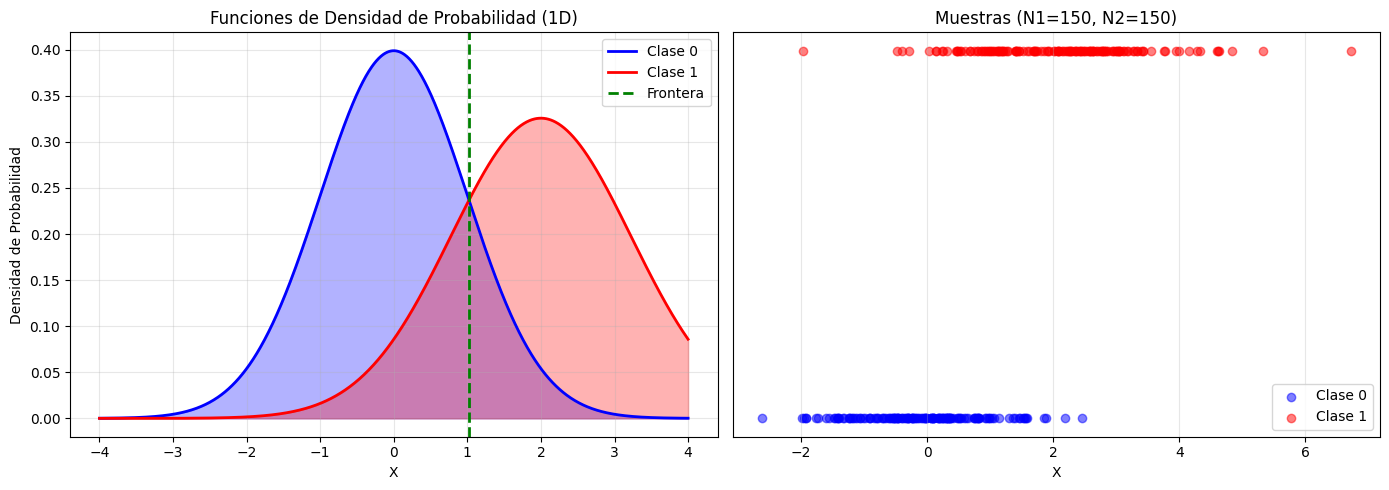

🔍 ¿Qué tipo de frontera se puede presentar en el caso 1D?
   En 1D, la frontera de decisión es un PUNTO (o varios puntos) en la recta numérica.
   Este punto es donde las densidades de probabilidad de ambas clases se igualan:
   f₀(x) = f₁(x)
   Si las distribuciones son normales, la ecuación es cuadrática en x, pudiendo tener:
   - 1 punto de cruce (caso más común)
   - 2 puntos de cruce (si las varianzas son muy diferentes)
   - 0 puntos (si una domina completamente a la otra)

📊 CASO 2D:
--------------------------------------------------


/tmp/ipykernel_144/1994514476.py:191: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X, Y, Z_diff, levels=[0], colors='green', linewidths=2,


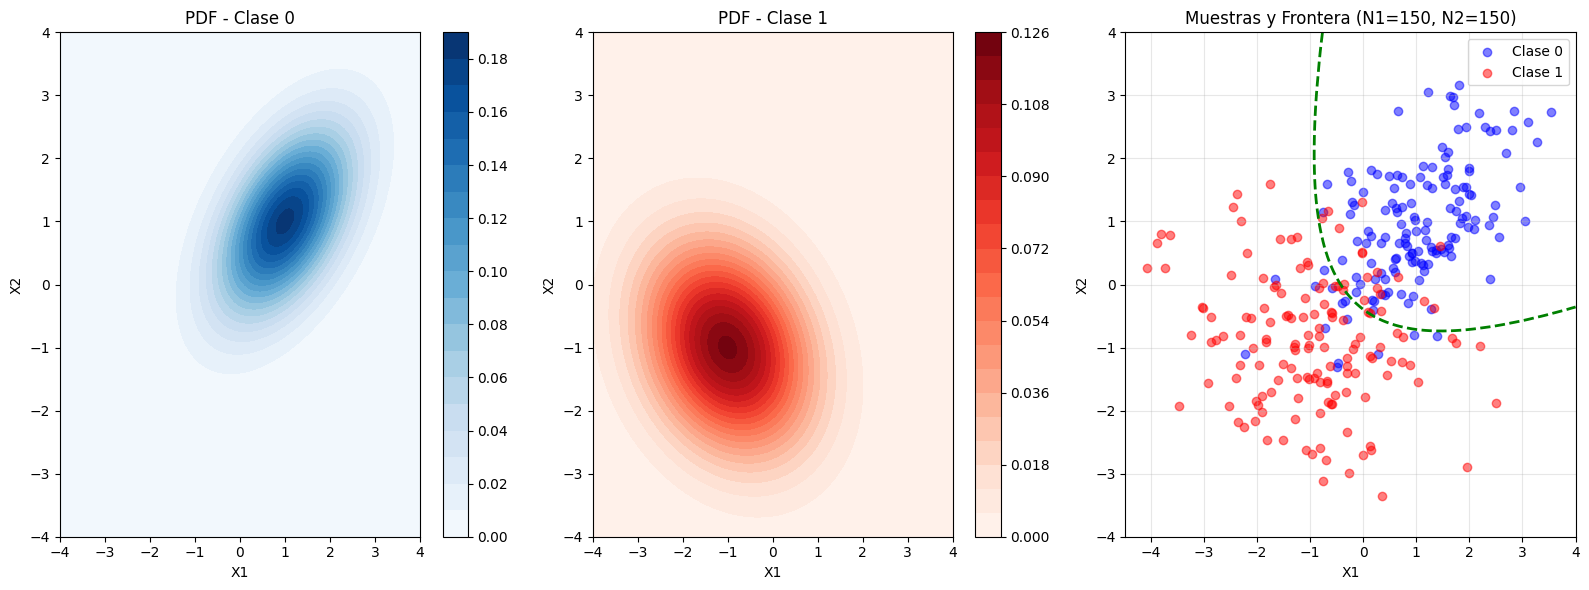

🔍 ¿Qué tipo de frontera se puede presentar en el caso 2D?
   En 2D, la frontera de decisión es una CURVA en el plano X1-X2.
   Para distribuciones normales, esta curva puede ser:
   - Una línea recta (si las matrices de covarianza son iguales)
   - Una curva cuadrática (elipse, parábola o hipérbola) si las covarianzas difieren
   La ecuación de la frontera es: f₀(x₁,x₂) = f₁(x₁,x₂)

📊 CASO 3D:
--------------------------------------------------


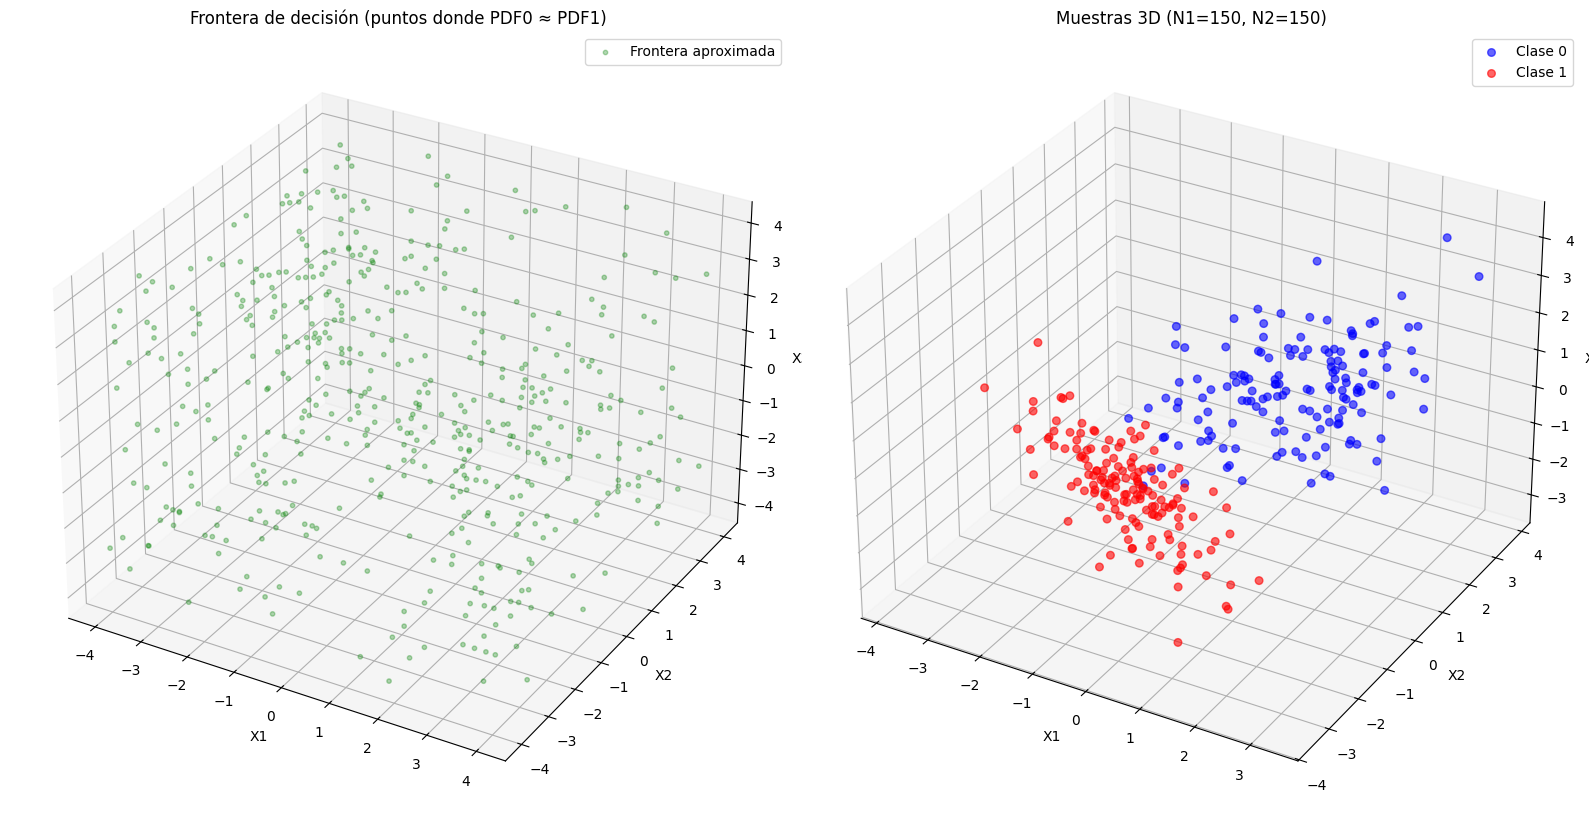

🔍 ¿Qué tipo de frontera se puede presentar en el caso 3D?
   En 3D, la frontera de decisión es una SUPERFICIE en el espacio tridimensional.
   Esta superficie puede ser:
   - Un plano (si las matrices de covarianza son iguales)
   - Una superficie cuadrática (paraboloide, hiperboloide, elipsoide) si las covarianzas difieren
   La ecuación de la frontera es: f₀(x₁,x₂,x₃) = f₁(x₁,x₂,x₃)

📊 CASO 4D (análisis teórico):
--------------------------------------------------
🔍 ¿Qué tipo de frontera se puede presentar en el caso 4D?
   En 4D, la frontera de decisión es un HIPERPLANO o HIPERSUPERFICIE en un espacio de 4 dimensiones.
   Características:
   - Es un objeto de dimensión 3 inmerso en un espacio de dimensión 4
   - Si las matrices de covarianza son iguales: hiperplano (dimensión 3)
   - Si las matrices difieren: hipersuperficie cuadrática
   - No podemos visualizarla directamente, pero podemos proyectarla o usar
     técnicas como PCA para reducir dimensionalidad

📐 ¿CÓMO ENCONTRAR LA F

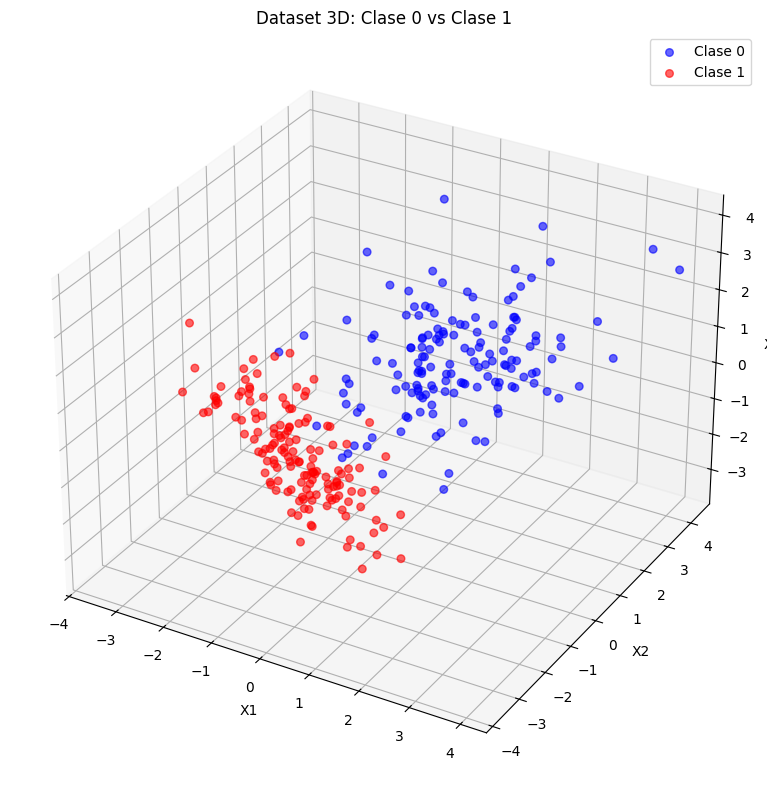


✅ Ejercicio completado!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import multivariate_normal
import pandas as pd

# Configuración inicial para reproducibilidad
np.random.seed(42)

# ============================================
# a) Distribuciones para clase 0 (en 1D, 2D y 3D)
# ============================================

# 1. Distribución en 1D (Clase 0)
# Una distribución normal univariada es un caso especial de multivariada con dimensión 1
mu_1d_clase0 = [0]  # Media
cov_1d_clase0 = [[1]]  # Varianza (matriz 1x1)
rv_1d_clase0 = multivariate_normal(mu_1d_clase0, cov_1d_clase0)

# 2. Distribución en 2D (Clase 0)
mu_2d_clase0 = [1, 1]  # Media en 2D
cov_2d_clase0 = [[1.0, 0.5], [0.5, 1.0]]  # Matriz de covarianza con correlación positiva
rv_2d_clase0 = multivariate_normal(mu_2d_clase0, cov_2d_clase0)

# 3. Distribución en 3D (Clase 0)
mu_3d_clase0 = [1, 1, 1]  # Media en 3D
cov_3d_clase0 = [[1.0, 0.3, 0.2],
                  [0.3, 1.0, 0.4],
                  [0.2, 0.4, 1.0]]  # Matriz de covarianza 3x3
rv_3d_clase0 = multivariate_normal(mu_3d_clase0, cov_3d_clase0)

# ============================================
# b) Distribución para clase 1 (en 3D)
# ============================================

# 4. Distribución en 3D (Clase 1)
mu_3d_clase1 = [-1, -1, -1]  # Media diferente
cov_3d_clase1 = [[1.0, -0.5, -0.3],
                  [-0.5, 1.0, -0.4],
                  [-0.3, -0.4, 1.0]]  # Matriz con correlaciones negativas
rv_3d_clase1 = multivariate_normal(mu_3d_clase1, cov_3d_clase1)

# ============================================
# Función para generar muestras
# ============================================

def sample_multivariate(rv_clase0, rv_clase1=None, N1=100, N2=100, dim=1, random_state=None):
    """
    Genera muestras de una o dos distribuciones multivariadas

    Parámetros:
    - rv_clase0: distribución para clase 0
    - rv_clase1: distribución para clase 1 (opcional)
    - N1, N2: número de muestras para cada clase
    - dim: dimensión de los datos
    - random_state: semilla para reproducibilidad
    """
    if rv_clase1 is None:
        # Caso de una sola distribución
        X = rv_clase0.rvs(N1 + N2, random_state=random_state)
        y = np.concatenate([np.zeros(N1), np.ones(N2)])
    else:
        # Caso de dos distribuciones diferentes
        X = np.concatenate([rv_clase0.rvs(N1, random_state=random_state),
                            rv_clase1.rvs(N2, random_state=random_state)])
        y = np.concatenate([np.zeros(N1), np.ones(N2)])

    return X, y

# ============================================
# Funciones para visualización
# ============================================

def plot_1d_distribution(rv_clase0, rv_clase1=None, N1=100, N2=100):
    """Visualiza distribuciones en 1D"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Generar datos para el eje x
    x = np.linspace(-4, 4, 1000)

    # Primer subplot: PDFs
    ax = axes[0]
    if rv_clase1 is None:
        pdf0 = rv_clase0.pdf(x.reshape(-1, 1))
        ax.plot(x, pdf0, 'b-', label='Clase 0', linewidth=2)
        ax.fill_between(x, 0, pdf0, alpha=0.3, color='blue')
    else:
        pdf0 = rv_clase0.pdf(x.reshape(-1, 1))
        pdf1 = rv_clase1.pdf(x.reshape(-1, 1))
        ax.plot(x, pdf0, 'b-', label='Clase 0', linewidth=2)
        ax.plot(x, pdf1, 'r-', label='Clase 1', linewidth=2)
        ax.fill_between(x, 0, pdf0, alpha=0.3, color='blue')
        ax.fill_between(x, 0, pdf1, alpha=0.3, color='red')

        # Encontrar punto de cruce (frontera de decisión aproximada)
        diff = pdf0 - pdf1
        cruces = np.where(np.diff(np.sign(diff)))[0]
        if len(cruces) > 0:
            for idx in cruces:
                ax.axvline(x[idx], color='green', linestyle='--', linewidth=2,
                          label='Frontera' if idx == cruces[0] else '')

    ax.set_xlabel('X')
    ax.set_ylabel('Densidad de Probabilidad')
    ax.set_title('Funciones de Densidad de Probabilidad (1D)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Segundo subplot: muestras
    ax = axes[1]
    if rv_clase1 is None:
        X, y = sample_multivariate(rv_clase0, None, N1, N2, dim=1)
        ax.scatter(X[y==0], np.zeros_like(X[y==0]), c='blue', alpha=0.5, label='Clase 0')
        ax.scatter(X[y==1], np.ones_like(X[y==1]), c='red', alpha=0.5, label='Clase 1')
    else:
        X, y = sample_multivariate(rv_clase0, rv_clase1, N1, N2, dim=1)
        ax.scatter(X[y==0], np.zeros_like(X[y==0]), c='blue', alpha=0.5, label='Clase 0')
        ax.scatter(X[y==1], np.ones_like(X[y==1]), c='red', alpha=0.5, label='Clase 1')

    ax.set_xlabel('X')
    ax.set_yticks([])
    ax.set_title(f'Muestras (N1={N1}, N2={N2})')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_2d_distribution(rv_clase0, rv_clase1=None, N1=100, N2=100):
    """Visualiza distribuciones en 2D"""
    fig = plt.figure(figsize=(16, 6))

    # Generar malla para visualización
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    if rv_clase1 is None:
        # Contorno de la PDF
        ax = fig.add_subplot(1, 3, 1)
        Z = rv_clase0.pdf(pos)
        contour = ax.contourf(X, Y, Z, levels=20, cmap='Blues')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_title('PDF - Clase 0 (2D)')
        plt.colorbar(contour, ax=ax)

        # Muestras
        ax = fig.add_subplot(1, 3, 2)
        X_sample, y_sample = sample_multivariate(rv_clase0, None, N1, N2, dim=2)
        ax.scatter(X_sample[y_sample==0][:,0], X_sample[y_sample==0][:,1],
                  c='blue', alpha=0.5, label='Clase 0')
        ax.scatter(X_sample[y_sample==1][:,0], X_sample[y_sample==1][:,1],
                  c='red', alpha=0.5, label='Clase 1')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_title('Muestras')
        ax.legend()
        ax.grid(True, alpha=0.3)

    else:
        # PDF de clase 0
        ax = fig.add_subplot(1, 3, 1)
        Z0 = rv_clase0.pdf(pos)
        contour0 = ax.contourf(X, Y, Z0, levels=20, cmap='Blues')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_title('PDF - Clase 0')
        plt.colorbar(contour0, ax=ax)

        # PDF de clase 1
        ax = fig.add_subplot(1, 3, 2)
        Z1 = rv_clase1.pdf(pos)
        contour1 = ax.contourf(X, Y, Z1, levels=20, cmap='Reds')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_title('PDF - Clase 1')
        plt.colorbar(contour1, ax=ax)

        # Muestras combinadas
        ax = fig.add_subplot(1, 3, 3)
        X_sample, y_sample = sample_multivariate(rv_clase0, rv_clase1, N1, N2, dim=2)
        ax.scatter(X_sample[y_sample==0][:,0], X_sample[y_sample==0][:,1],
                  c='blue', alpha=0.5, label='Clase 0')
        ax.scatter(X_sample[y_sample==1][:,0], X_sample[y_sample==1][:,1],
                  c='red', alpha=0.5, label='Clase 1')

        # Calcular y dibujar frontera de decisión aproximada
        Z_diff = Z0 - Z1
        ax.contour(X, Y, Z_diff, levels=[0], colors='green', linewidths=2,
                  linestyles='--', label='Frontera')

        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_title(f'Muestras y Frontera (N1={N1}, N2={N2})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_3d_distribution(rv_clase0, rv_clase1=None, N1=100, N2=100):
    """Visualiza distribuciones en 3D"""

    if rv_clase1 is None:
        # Visualización 3D con proyecciones para una sola clase
        fig = plt.figure(figsize=(16, 6))

        # Generar datos para visualización 3D
        x = np.linspace(-4, 4, 30)
        y = np.linspace(-4, 4, 30)
        z = np.linspace(-4, 4, 30)
        X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
        pos = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

        # Calcular PDF (tomamos un subconjunto para no saturar la memoria)
        pdf_values = rv_clase0.pdf(pos)
        pdf_values = pdf_values.reshape(X.shape)

        # Visualización con cortes
        ax = fig.add_subplot(1, 2, 1, projection='3d')

        # Tomar cortes en diferentes planos
        idx_x = len(x) // 2
        idx_y = len(y) // 2
        idx_z = len(z) // 2

        # Corte en plano YZ (x constante)
        y_plane, z_plane = np.meshgrid(y, z)
        ax.plot_surface(np.full_like(y_plane, x[idx_x]), y_plane, z_plane,
                       facecolors=plt.cm.Blues(pdf_values[idx_x, :, :] / pdf_values.max()),
                       alpha=0.7, linewidth=0, antialiased=True)

        # Corte en plano XZ (y constante)
        x_plane, z_plane = np.meshgrid(x, z)
        ax.plot_surface(x_plane, np.full_like(x_plane, y[idx_y]), z_plane,
                       facecolors=plt.cm.Blues(pdf_values[:, idx_y, :].T / pdf_values.max()),
                       alpha=0.7, linewidth=0, antialiased=True)

        # Corte en plano XY (z constante)
        x_plane, y_plane = np.meshgrid(x, y)
        ax.plot_surface(x_plane, y_plane, np.full_like(x_plane, z[idx_z]),
                       facecolors=plt.cm.Blues(pdf_values[:, :, idx_z] / pdf_values.max()),
                       alpha=0.7, linewidth=0, antialiased=True)

        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('X3')
        ax.set_title('PDF - Clase 0 (3D) - Cortes ortogonales')

        # Muestras
        ax = fig.add_subplot(1, 2, 2, projection='3d')
        X_sample, y_sample = sample_multivariate(rv_clase0, None, N1, N2, dim=3)

        ax.scatter(X_sample[y_sample==0][:,0], X_sample[y_sample==0][:,1],
                  X_sample[y_sample==0][:,2], c='blue', alpha=0.5, s=20, label='Clase 0')
        ax.scatter(X_sample[y_sample==1][:,0], X_sample[y_sample==1][:,1],
                  X_sample[y_sample==1][:,2], c='red', alpha=0.5, s=20, label='Clase 1')

        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('X3')
        ax.set_title('Muestras 3D')
        ax.legend()

    else:
        # Visualización para dos clases en 3D
        fig = plt.figure(figsize=(16, 10))

        # Generar datos para visualización (usamos una malla más gruesa para no saturar)
        x = np.linspace(-4, 4, 20)
        y = np.linspace(-4, 4, 20)
        z = np.linspace(-4, 4, 20)
        X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
        pos = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

        # Calcular PDFs
        pdf0 = rv_clase0.pdf(pos).reshape(X.shape)
        pdf1 = rv_clase1.pdf(pos).reshape(X.shape)
        pdf_diff = pdf0 - pdf1

        # Visualización 3D con cortes y frontera
        ax = fig.add_subplot(1, 2, 1, projection='3d')

        # Encontrar puntos cerca de la frontera (donde pdf_diff ≈ 0)
        threshold = 0.01
        frontier_mask = np.abs(pdf_diff) < threshold * max(pdf0.max(), pdf1.max())

        # Mostrar algunos puntos de la frontera
        frontier_points = pos[frontier_mask.ravel()]
        if len(frontier_points) > 0:
            # Tomar una muestra aleatoria para no saturar
            if len(frontier_points) > 500:
                idx = np.random.choice(len(frontier_points), 500, replace=False)
                frontier_points = frontier_points[idx]

            ax.scatter(frontier_points[:,0], frontier_points[:,1], frontier_points[:,2],
                      c='green', alpha=0.3, s=10, label='Frontera aproximada')

        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('X3')
        ax.set_title('Frontera de decisión (puntos donde PDF0 ≈ PDF1)')
        ax.legend()

        # Muestras
        ax = fig.add_subplot(1, 2, 2, projection='3d')
        X_sample, y_sample = sample_multivariate(rv_clase0, rv_clase1, N1, N2, dim=3)

        ax.scatter(X_sample[y_sample==0][:,0], X_sample[y_sample==0][:,1],
                  X_sample[y_sample==0][:,2], c='blue', alpha=0.6, s=30, label='Clase 0')
        ax.scatter(X_sample[y_sample==1][:,0], X_sample[y_sample==1][:,1],
                  X_sample[y_sample==1][:,2], c='red', alpha=0.6, s=30, label='Clase 1')

        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('X3')
        ax.set_title(f'Muestras 3D (N1={N1}, N2={N2})')
        ax.legend()

    plt.tight_layout()
    plt.show()

# ============================================
# Análisis de fronteras de decisión
# ============================================

print("=" * 70)
print("ANÁLISIS DE FRONTERAS DE DECISIÓN")
print("=" * 70)

# 1D
print("\n📊 CASO 1D:")
print("-" * 50)
# Crear dos distribuciones 1D para visualizar frontera
mu_1d_clase1 = [2]  # Media diferente para clase 1
cov_1d_clase1 = [[1.5]]  # Varianza diferente
rv_1d_clase1 = multivariate_normal(mu_1d_clase1, cov_1d_clase1)

plot_1d_distribution(rv_1d_clase0, rv_1d_clase1, N1=150, N2=150)

print("🔍 ¿Qué tipo de frontera se puede presentar en el caso 1D?")
print("   En 1D, la frontera de decisión es un PUNTO (o varios puntos) en la recta numérica.")
print("   Este punto es donde las densidades de probabilidad de ambas clases se igualan:")
print("   f₀(x) = f₁(x)")
print("   Si las distribuciones son normales, la ecuación es cuadrática en x, pudiendo tener:")
print("   - 1 punto de cruce (caso más común)")
print("   - 2 puntos de cruce (si las varianzas son muy diferentes)")
print("   - 0 puntos (si una domina completamente a la otra)")

# 2D
print("\n📊 CASO 2D:")
print("-" * 50)
# Crear dos distribuciones 2D
mu_2d_clase1 = [-1, -1]  # Media diferente
cov_2d_clase1 = [[1.5, -0.3], [-0.3, 1.2]]  # Covarianza diferente
rv_2d_clase1 = multivariate_normal(mu_2d_clase1, cov_2d_clase1)

plot_2d_distribution(rv_2d_clase0, rv_2d_clase1, N1=150, N2=150)

print("🔍 ¿Qué tipo de frontera se puede presentar en el caso 2D?")
print("   En 2D, la frontera de decisión es una CURVA en el plano X1-X2.")
print("   Para distribuciones normales, esta curva puede ser:")
print("   - Una línea recta (si las matrices de covarianza son iguales)")
print("   - Una curva cuadrática (elipse, parábola o hipérbola) si las covarianzas difieren")
print("   La ecuación de la frontera es: f₀(x₁,x₂) = f₁(x₁,x₂)")

# 3D
print("\n📊 CASO 3D:")
print("-" * 50)
# Usar las distribuciones 3D definidas al inicio
plot_3d_distribution(rv_3d_clase0, rv_3d_clase1, N1=150, N2=150)

print("🔍 ¿Qué tipo de frontera se puede presentar en el caso 3D?")
print("   En 3D, la frontera de decisión es una SUPERFICIE en el espacio tridimensional.")
print("   Esta superficie puede ser:")
print("   - Un plano (si las matrices de covarianza son iguales)")
print("   - Una superficie cuadrática (paraboloide, hiperboloide, elipsoide) si las covarianzas difieren")
print("   La ecuación de la frontera es: f₀(x₁,x₂,x₃) = f₁(x₁,x₂,x₃)")

print("\n📊 CASO 4D (análisis teórico):")
print("-" * 50)
print("🔍 ¿Qué tipo de frontera se puede presentar en el caso 4D?")
print("   En 4D, la frontera de decisión es un HIPERPLANO o HIPERSUPERFICIE en un espacio de 4 dimensiones.")
print("   Características:")
print("   - Es un objeto de dimensión 3 inmerso en un espacio de dimensión 4")
print("   - Si las matrices de covarianza son iguales: hiperplano (dimensión 3)")
print("   - Si las matrices difieren: hipersuperficie cuadrática")
print("   - No podemos visualizarla directamente, pero podemos proyectarla o usar")
print("     técnicas como PCA para reducir dimensionalidad")

# ============================================
# ¿Cómo encontrar la frontera de decisión?
# ============================================

print("\n" + "=" * 70)
print("📐 ¿CÓMO ENCONTRAR LA FRONTERA DE DECISIÓN?")
print("=" * 70)

print("""
MÉTODOS PARA ENCONTRAR LA FRONTERA:

1️⃣ MÉTODO ANALÍTICO (para distribuciones normales):
   La frontera se encuentra resolviendo la ecuación:
   P(Y=0|X) = P(Y=1|X)

   Aplicando Bayes y considerando probabilidades a priori iguales:
   f₀(x) = f₁(x)

   Para normales multivariadas, esto lleva a una ecuación cuadrática:
   (x-μ₀)ᵀΣ₀⁻¹(x-μ₀) - (x-μ₁)ᵀΣ₁⁻¹(x-μ₁) + ln|Σ₀| - ln|Σ₁| = 0

   Casos especiales:
   - Si Σ₀ = Σ₁ = Σ: la ecuación se reduce a una LINEA RECTA (discriminante lineal)
     (μ₁ - μ₀)ᵀΣ⁻¹x + constante = 0

   - Si Σ₀ ≠ Σ₁: la ecuación es CUADRÁTICA (discriminante cuadrático)

2️⃣ MÉTODO DE CUADRÍCULA (para visualización en 2D/3D):
   - Crear una malla de puntos en el espacio
   - Evaluar f₀ y f₁ en cada punto
   - Encontrar donde |f₀ - f₁| < ε

3️⃣ MÉTODO DE APRENDIZAJE AUTOMÁTICO:
   - Entrenar un clasificador (regresión logística, SVM, redes neuronales)
   - Extraer la frontera aprendida por el modelo

4️⃣ MÉTODO DE MONTE CARLO:
   - Generar muchas muestras de ambas distribuciones
   - Entrenar un clasificador simple
   - Usar el clasificador para predecir en una malla de puntos
""")

# Ejemplo práctico de cómo encontrar la frontera en 2D
print("\n📝 EJEMPLO PRÁCTICO (código para encontrar frontera en 2D):")
print("""
def encontrar_frontera_2d(rv0, rv1, x_range=(-4,4), y_range=(-4,4), n_points=100):
    \"\"\"
    Encuentra puntos aproximados de la frontera de decisión en 2D
    \"\"\"
    x = np.linspace(x_range[0], x_range[1], n_points)
    y = np.linspace(y_range[0], y_range[1], n_points)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    # Calcular PDFs
    Z0 = rv0.pdf(pos)
    Z1 = rv1.pdf(pos)

    # Encontrar donde se cruzan
    Z_diff = Z0 - Z1
    cruces = np.where(np.abs(Z_diff) < 0.01 * max(Z0.max(), Z1.max()))

    return X[cruces], Y[cruces]

# Uso:
# x_front, y_front = encontrar_frontera_2d(rv_2d_clase0, rv_2d_clase1)
# plt.scatter(x_front, y_front, c='green', s=1)
""")

# ============================================
# Generar dataset final para sonificación (opcional)
# ============================================

print("\n" + "=" * 70)
print("🎵 GENERANDO DATASET PARA SONIFICACIÓN (3D)")
print("=" * 70)

# Generar muestras para el dataset final
X_samples, y_labels = sample_multivariate(rv_3d_clase0, rv_3d_clase1, N1=150, N2=150, dim=3)

# Crear DataFrame
df_3d = pd.DataFrame(X_samples, columns=['X1', 'X2', 'X3'])
df_3d['Y'] = y_labels.astype(int)

print(f"\nDataset 3D generado con {len(df_3d)} muestras:")
print(f"- Clase 0: {(df_3d['Y'] == 0).sum()} muestras")
print(f"- Clase 1: {(df_3d['Y'] == 1).sum()} muestras")
print("\nPrimeras 5 filas:")
print(df_3d.head())

# Estadísticas básicas
print("\n📊 Estadísticas por clase:")
print(df_3d.groupby('Y').describe())

# Visualización final de las muestras 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Separar por clase
clase0 = df_3d[df_3d['Y'] == 0]
clase1 = df_3d[df_3d['Y'] == 1]

ax.scatter(clase0['X1'], clase0['X2'], clase0['X3'],
           c='blue', alpha=0.6, s=30, label='Clase 0')
ax.scatter(clase1['X1'], clase1['X2'], clase1['X3'],
           c='red', alpha=0.6, s=30, label='Clase 1')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Dataset 3D: Clase 0 vs Clase 1')
ax.legend()

plt.tight_layout()
plt.show()

print("\n✅ Ejercicio completado!")

VISUALIZACIÓN DE LA FRONTERA DE DECISIÓN EN 3D

📊 MÉTODO 1: Puntos donde las PDFs se igualan
--------------------------------------------------
Puntos encontrados en la frontera: 18134

📊 MÉTODO 2: Cortes en planos con curvas de nivel
--------------------------------------------------

📊 MÉTODO 3: Muestras de ambas clases con superficie de frontera
--------------------------------------------------


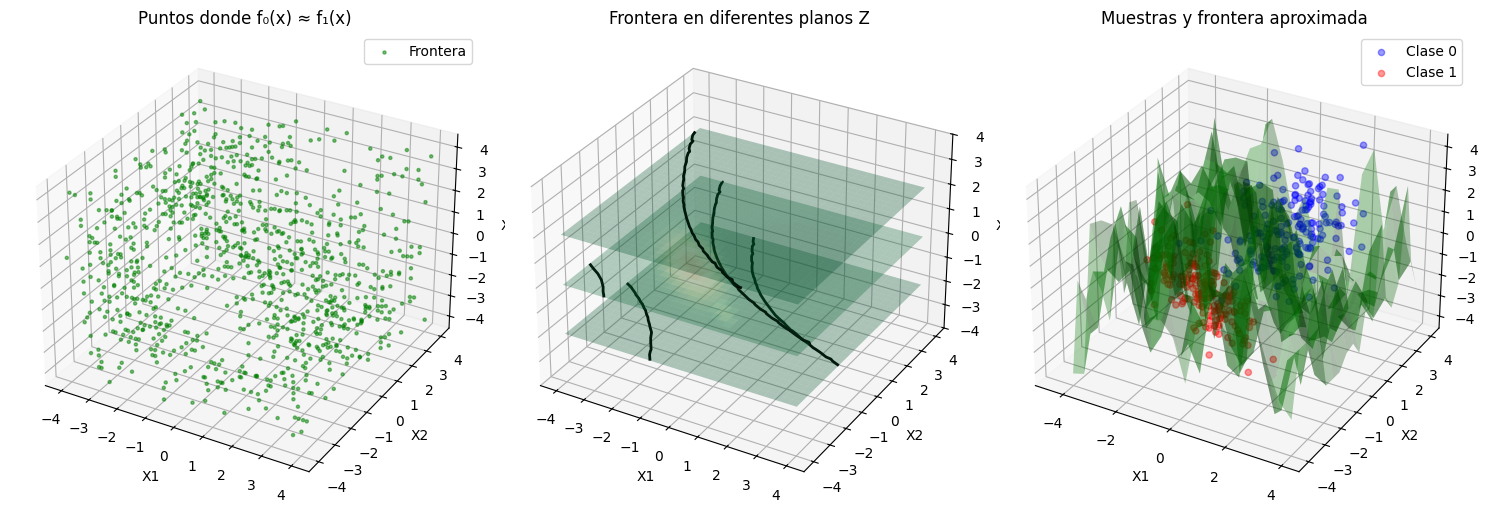


📊 MÉTODO 4: Proyecciones 2D de la frontera
--------------------------------------------------


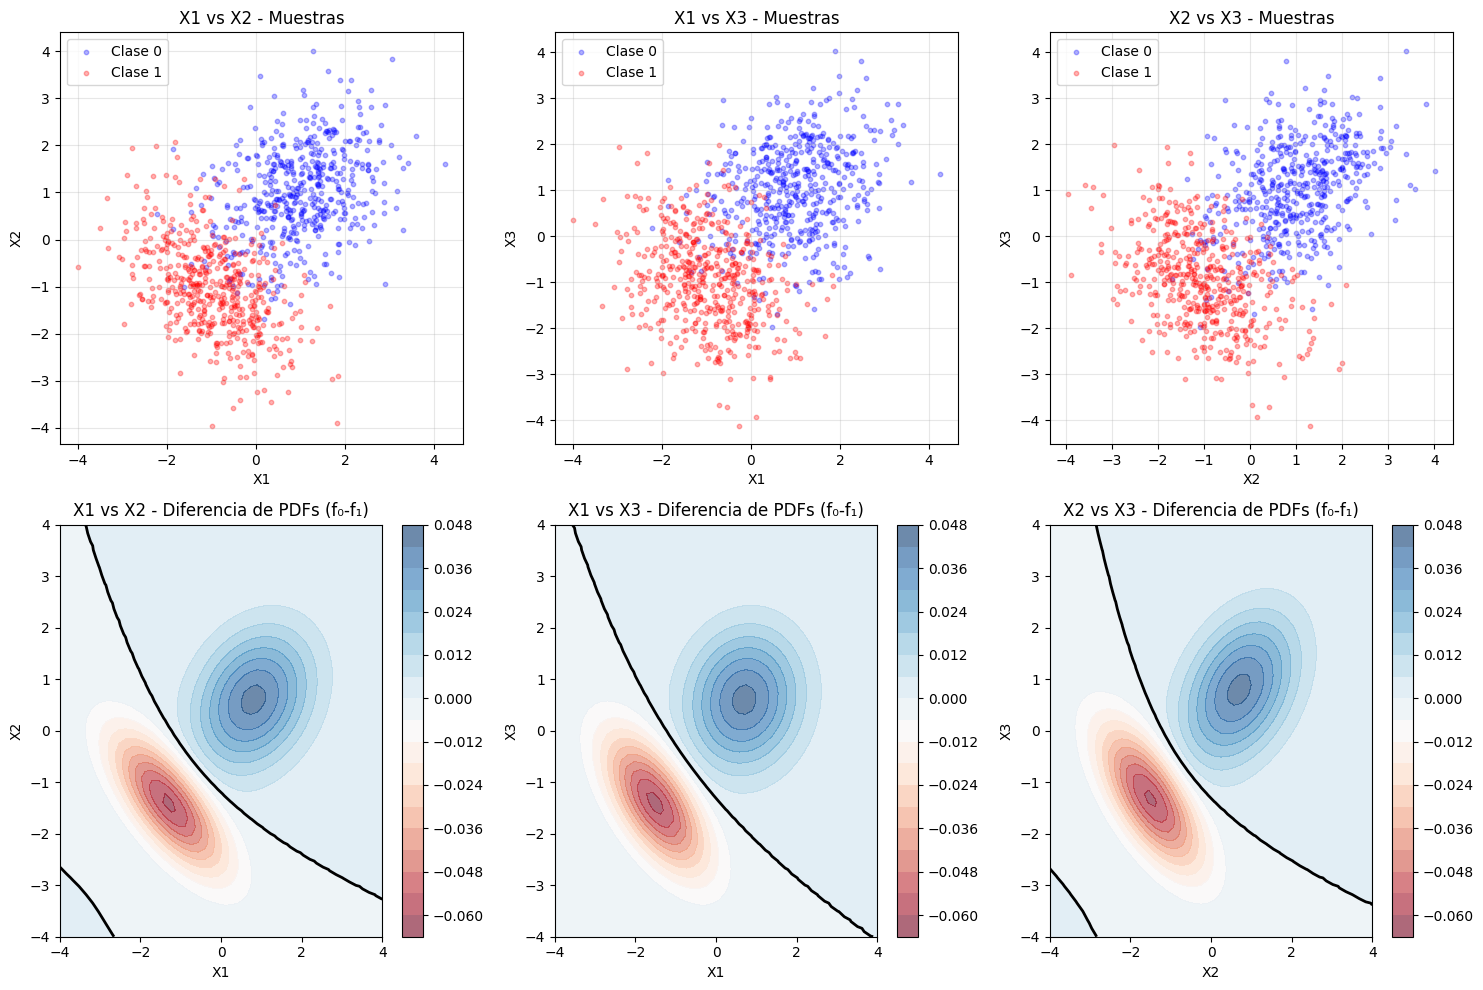


📊 MÉTODO 5: Superficie de frontera 3D
--------------------------------------------------
Calculando superficie de frontera...


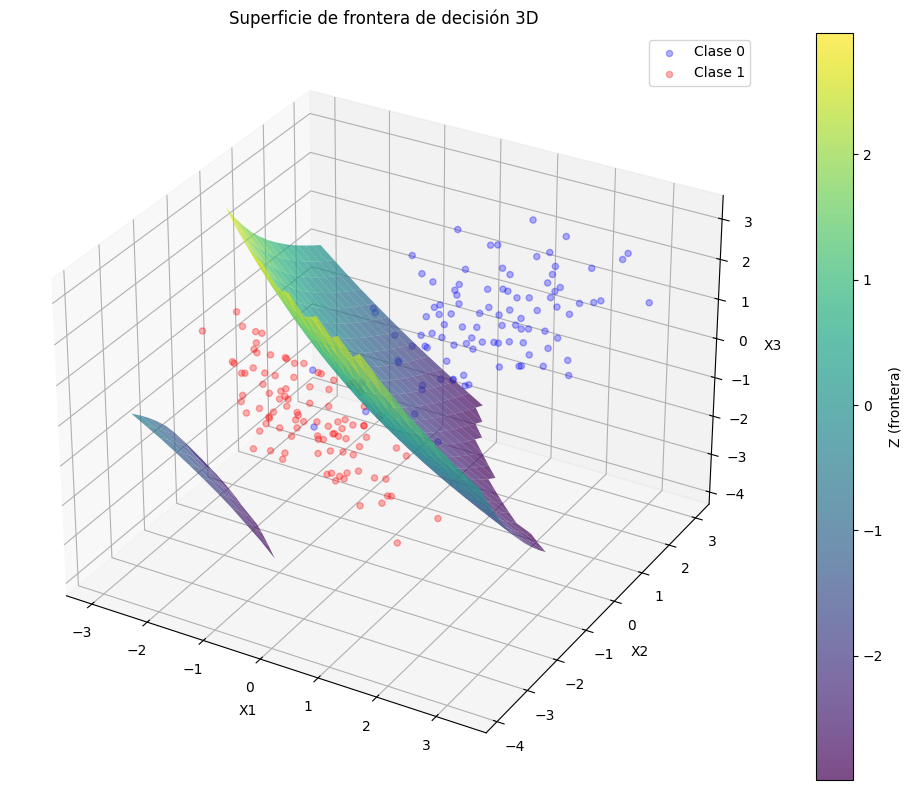


📊 MÉTODO 6: Vistas múltiples de la misma frontera
--------------------------------------------------


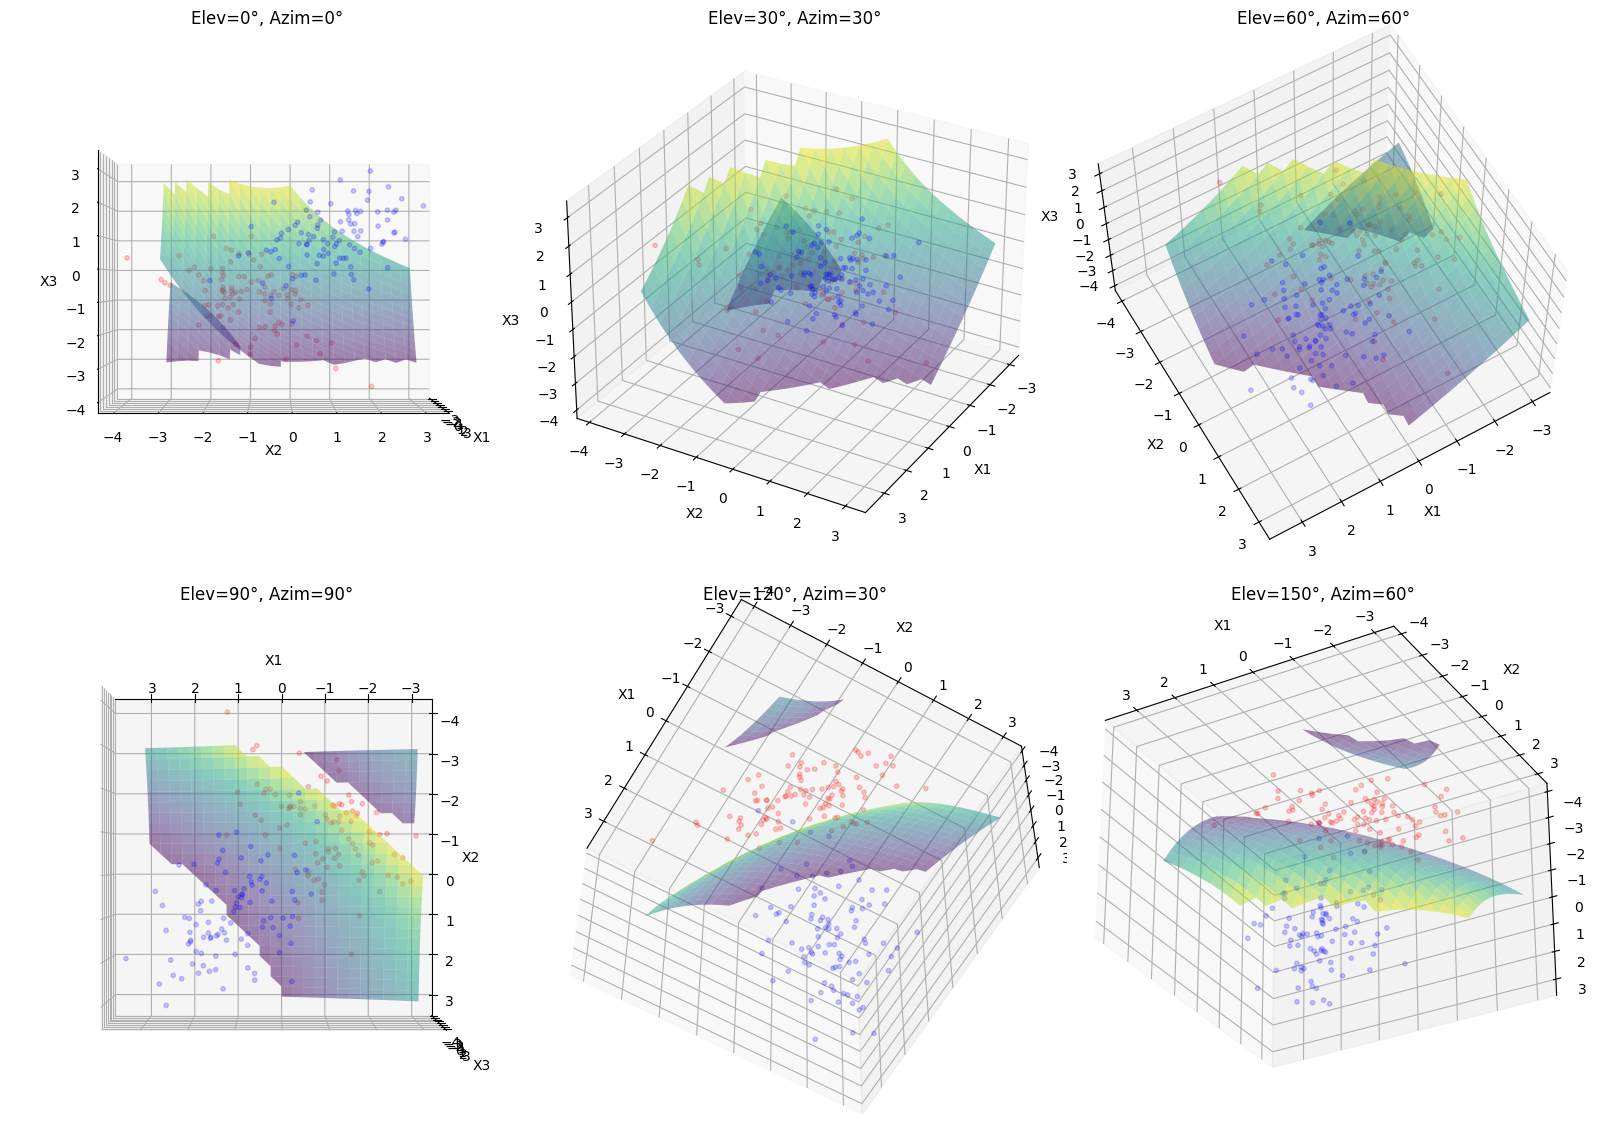


📐 ANÁLISIS DE LA FRONTERA DE DECISIÓN EN 3D

Características de la frontera observada:

1️⃣ FORMA GEOMÉTRICA:
   - La frontera es una SUPERFICIE CURVA en el espacio 3D
   - No es un plano perfecto porque las matrices de covarianza son diferentes
   - La superficie separa las regiones donde domina cada clase

2️⃣ ECUACIÓN DE LA FRONTERA:
   f₀(x₁,x₂,x₃) = f₁(x₁,x₂,x₃)
   
   Para normales multivariadas:
   (x-μ₀)ᵀΣ₀⁻¹(x-μ₀) - (x-μ₁)ᵀΣ₁⁻¹(x-μ₁) + ln|Σ₀| - ln|Σ₁| = 0

3️⃣ PROPIEDADES:
   - La superficie puede ser no conexa (puede tener "agujeros")
   - El grosor de la región de transición depende de las varianzas
   - Cerca de los centroides, domina la clase correspondiente

4️⃣ VISUALIZACIÓN:
   - Podemos ver cortes en diferentes planos para entender su estructura
   - Las proyecciones 2D muestran cómo se ve la frontera desde diferentes perspectivas
   - La superficie completa nos da una idea de la verdadera forma 3D


🎬 Para ver la frontera desde todos los ángulos, ejecuta:

from IPyth

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

# Configuración inicial
np.random.seed(42)

# ============================================
# Definir distribuciones para clase 0 y clase 1 en 3D
# ============================================

# Clase 0
mu_3d_clase0 = [1, 1, 1]
cov_3d_clase0 = [[1.0, 0.3, 0.2],
                 [0.3, 1.0, 0.4],
                 [0.2, 0.4, 1.0]]
rv_3d_clase0 = multivariate_normal(mu_3d_clase0, cov_3d_clase0)

# Clase 1
mu_3d_clase1 = [-1, -1, -1]
cov_3d_clase1 = [[1.0, -0.5, -0.3],
                 [-0.5, 1.0, -0.4],
                 [-0.3, -0.4, 1.0]]
rv_3d_clase1 = multivariate_normal(mu_3d_clase1, cov_3d_clase1)

print("=" * 70)
print("VISUALIZACIÓN DE LA FRONTERA DE DECISIÓN EN 3D")
print("=" * 70)

# ============================================
# 1. Visualización con malla 3D y puntos de frontera
# ============================================

print("\n📊 MÉTODO 1: Puntos donde las PDFs se igualan")
print("-" * 50)

# Crear una malla 3D más fina para mejor visualización
x = np.linspace(-4, 4, 30)
y = np.linspace(-4, 4, 30)
z = np.linspace(-4, 4, 30)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Preparar puntos para evaluación
pos = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

# Calcular PDFs
pdf0 = rv_3d_clase0.pdf(pos).reshape(X.shape)
pdf1 = rv_3d_clase1.pdf(pos).reshape(X.shape)
pdf_diff = pdf0 - pdf1

# Encontrar puntos cerca de la frontera (donde las PDFs son aproximadamente iguales)
threshold = 0.005
frontier_mask = np.abs(pdf_diff) < threshold * max(pdf0.max(), pdf1.max())
frontier_points = pos[frontier_mask.ravel()]

print(f"Puntos encontrados en la frontera: {len(frontier_points)}")

# Visualización 3D
fig = plt.figure(figsize=(15, 5))

# Subplot 1: Puntos de frontera
ax1 = fig.add_subplot(131, projection='3d')
if len(frontier_points) > 0:
    # Si hay muchos puntos, tomar una muestra
    if len(frontier_points) > 1000:
        idx = np.random.choice(len(frontier_points), 1000, replace=False)
        plot_points = frontier_points[idx]
    else:
        plot_points = frontier_points

    ax1.scatter(plot_points[:,0], plot_points[:,1], plot_points[:,2],
               c='green', alpha=0.5, s=5, label='Frontera')

ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')
ax1.set_title('Puntos donde f₀(x) ≈ f₁(x)')
ax1.legend()

# ============================================
# 2. Visualización con cortes en diferentes planos
# ============================================

print("\n📊 MÉTODO 2: Cortes en planos con curvas de nivel")
print("-" * 50)

ax2 = fig.add_subplot(132, projection='3d')

# Tomar cortes en diferentes valores de z
z_slices = [-2, 0, 2]

for z_val in z_slices:
    # Encontrar el índice más cercano
    z_idx = np.argmin(np.abs(z - z_val))

    # Crear malla 2D para el corte
    X_slice, Y_slice = np.meshgrid(x, y)

    # Obtener la diferencia de PDFs en ese corte
    diff_slice = pdf_diff[:, :, z_idx]

    # Graficar la superficie de la diferencia
    ax2.plot_surface(X_slice, Y_slice, np.full_like(X_slice, z_val),
                    facecolors=plt.cm.RdYlGn((diff_slice + 0.1) / (diff_slice.max() - diff_slice.min())),
                    alpha=0.3, linewidth=0)

    # Dibujar la frontera (contorno donde diff = 0)
    ax2.contour(X_slice, Y_slice, diff_slice, levels=[0],
                colors='black', linewidths=2, offset=z_val)

ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('X3')
ax2.set_title('Frontera en diferentes planos Z')
ax2.set_zlim(-4, 4)

# ============================================
# 3. Visualización con muestras y superficie de frontera
# ============================================

print("\n📊 MÉTODO 3: Muestras de ambas clases con superficie de frontera")
print("-" * 50)

ax3 = fig.add_subplot(133, projection='3d')

# Generar muestras
N1, N2 = 200, 200
X0 = rv_3d_clase0.rvs(N1)
X1 = rv_3d_clase1.rvs(N2)

# Graficar muestras
ax3.scatter(X0[:,0], X0[:,1], X0[:,2], c='blue', alpha=0.4, s=20, label='Clase 0')
ax3.scatter(X1[:,0], X1[:,1], X1[:,2], c='red', alpha=0.4, s=20, label='Clase 1')

# Intentar aproximar la superficie de frontera
if len(frontier_points) > 100:
    # Usar los puntos de frontera para crear una superficie aproximada
    from scipy.interpolate import griddata

    # Tomar puntos de frontera para interpolación
    frontier_sample = frontier_points[::10]  # Muestrear cada 10 puntos

    if len(frontier_sample) > 10:
        # Crear una malla para la superficie
        u = np.linspace(-4, 4, 20)
        v = np.linspace(-4, 4, 20)
        U, V = np.meshgrid(u, v)

        # Interpolar Z en función de X e Y
        try:
            W = griddata(frontier_sample[:, :2], frontier_sample[:, 2], (U, V), method='linear')
            ax3.plot_surface(U, V, W, alpha=0.3, color='green', linewidth=0)
        except:
            # Si falla la interpolación, graficar puntos
            ax3.scatter(frontier_sample[:,0], frontier_sample[:,1], frontier_sample[:,2],
                       c='green', alpha=0.3, s=5)

ax3.set_xlabel('X1')
ax3.set_ylabel('X2')
ax3.set_zlabel('X3')
ax3.set_title('Muestras y frontera aproximada')
ax3.legend()

plt.tight_layout()
plt.show()

# ============================================
# 4. Visualización con proyecciones 2D
# ============================================

print("\n📊 MÉTODO 4: Proyecciones 2D de la frontera")
print("-" * 50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Generar más muestras para las proyecciones
X0 = rv_3d_clase0.rvs(500)
X1 = rv_3d_clase1.rvs(500)

# Proyecciones en diferentes planos
projections = [
    ('X1 vs X2', [0, 1], 'X1', 'X2'),
    ('X1 vs X3', [0, 2], 'X1', 'X3'),
    ('X2 vs X3', [1, 2], 'X2', 'X3')
]

for idx, (title, dims, xlabel, ylabel) in enumerate(projections):
    # Primera fila: scatter plots
    ax = axes[0, idx]
    ax.scatter(X0[:, dims[0]], X0[:, dims[1]], c='blue', alpha=0.3, s=10, label='Clase 0')
    ax.scatter(X1[:, dims[0]], X1[:, dims[1]], c='red', alpha=0.3, s=10, label='Clase 1')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} - Muestras')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Segunda fila: densidad y frontera
    ax = axes[1, idx]

    # Crear malla 2D
    x_vals = np.linspace(-4, 4, 50)
    y_vals = np.linspace(-4, 4, 50)
    X_mesh, Y_mesh = np.meshgrid(x_vals, y_vals)

    # Preparar puntos para evaluar (con la tercera dimensión fija en 0)
    pos_2d = np.column_stack([X_mesh.ravel(), Y_mesh.ravel()])

    if dims == [0, 1]:  # Plano XY, Z=0
        pos_eval = np.column_stack([pos_2d, np.zeros(len(pos_2d))])
    elif dims == [0, 2]:  # Plano XZ, Y=0
        pos_eval = np.column_stack([pos_2d[:,0:1], np.zeros(len(pos_2d)), pos_2d[:,1:2]])
    else:  # Plano YZ, X=0
        pos_eval = np.column_stack([np.zeros(len(pos_2d)), pos_2d])

    # Calcular diferencia de PDFs
    diff_2d = rv_3d_clase0.pdf(pos_eval) - rv_3d_clase1.pdf(pos_eval)
    diff_2d = diff_2d.reshape(X_mesh.shape)

    # Graficar contornos de la diferencia
    contour = ax.contourf(X_mesh, Y_mesh, diff_2d, levels=20, cmap='RdBu', alpha=0.6)
    ax.contour(X_mesh, Y_mesh, diff_2d, levels=[0], colors='black', linewidths=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} - Diferencia de PDFs (f₀-f₁)')
    plt.colorbar(contour, ax=ax)

plt.tight_layout()
plt.show()

# ============================================
# 5. Visualización de la frontera como superficie 3D
# ============================================

print("\n📊 MÉTODO 5: Superficie de frontera 3D")
print("-" * 50)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Crear una malla más fina para la superficie
x_fine = np.linspace(-3, 3, 25)
y_fine = np.linspace(-3, 3, 25)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)

# Para cada punto (x,y), encontrar el valor de z donde las PDFs se igualan
Z_front = np.zeros_like(X_fine)

print("Calculando superficie de frontera...")
for i in range(len(x_fine)):
    for j in range(len(y_fine)):
        x_val = X_fine[j, i]
        y_val = Y_fine[j, i]

        # Evaluar PDFs a lo largo de z
        z_vals = np.linspace(-3, 3, 50)
        points = np.column_stack([np.full_like(z_vals, x_val),
                                  np.full_like(z_vals, y_val),
                                  z_vals])

        pdf0_z = rv_3d_clase0.pdf(points)
        pdf1_z = rv_3d_clase1.pdf(points)
        diff_z = pdf0_z - pdf1_z

        # Encontrar donde cambia de signo (cruce por cero)
        sign_changes = np.where(np.diff(np.sign(diff_z)))[0]

        if len(sign_changes) > 0:
            # Tomar el primer cruce
            idx = sign_changes[0]
            # Interpolar para mejor precisión
            z1, z2 = z_vals[idx], z_vals[idx+1]
            d1, d2 = diff_z[idx], diff_z[idx+1]
            if d2 != d1:
                Z_front[j, i] = z1 - d1 * (z2 - z1) / (d2 - d1)
            else:
                Z_front[j, i] = z1
        else:
            Z_front[j, i] = np.nan

# Graficar la superficie
surf = ax.plot_surface(X_fine, Y_fine, Z_front, cmap='viridis',
                       alpha=0.7, linewidth=0, antialiased=True)

# Añadir las muestras para referencia
X0_sample = rv_3d_clase0.rvs(100)
X1_sample = rv_3d_clase1.rvs(100)
ax.scatter(X0_sample[:,0], X0_sample[:,1], X0_sample[:,2],
          c='blue', alpha=0.3, s=20, label='Clase 0')
ax.scatter(X1_sample[:,0], X1_sample[:,1], X1_sample[:,2],
          c='red', alpha=0.3, s=20, label='Clase 1')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Superficie de frontera de decisión 3D')
ax.legend()
plt.colorbar(surf, ax=ax, label='Z (frontera)')

plt.tight_layout()
plt.show()

# ============================================
# 6. Visualización interactiva (estática pero con rotación automática)
# ============================================

print("\n📊 MÉTODO 6: Vistas múltiples de la misma frontera")
print("-" * 50)

fig = plt.figure(figsize=(16, 12))

# Diferentes ángulos de vista
angles = [(0, 0), (30, 30), (60, 60), (90, 90), (120, 30), (150, 60)]

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(2, 3, idx+1, projection='3d')

    # Graficar muestras
    ax.scatter(X0_sample[:,0], X0_sample[:,1], X0_sample[:,2],
              c='blue', alpha=0.2, s=10)
    ax.scatter(X1_sample[:,0], X1_sample[:,1], X1_sample[:,2],
              c='red', alpha=0.2, s=10)

    # Graficar superficie de frontera
    ax.plot_surface(X_fine, Y_fine, Z_front, cmap='viridis',
                   alpha=0.5, linewidth=0)

    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'Elev={elev}°, Azim={azim}°')
    ax.view_init(elev=elev, azim=azim)

plt.tight_layout()
plt.show()

# ============================================
# Análisis de la frontera
# ============================================

print("\n" + "=" * 70)
print("📐 ANÁLISIS DE LA FRONTERA DE DECISIÓN EN 3D")
print("=" * 70)

print("""
Características de la frontera observada:

1️⃣ FORMA GEOMÉTRICA:
   - La frontera es una SUPERFICIE CURVA en el espacio 3D
   - No es un plano perfecto porque las matrices de covarianza son diferentes
   - La superficie separa las regiones donde domina cada clase

2️⃣ ECUACIÓN DE LA FRONTERA:
   f₀(x₁,x₂,x₃) = f₁(x₁,x₂,x₃)

   Para normales multivariadas:
   (x-μ₀)ᵀΣ₀⁻¹(x-μ₀) - (x-μ₁)ᵀΣ₁⁻¹(x-μ₁) + ln|Σ₀| - ln|Σ₁| = 0

3️⃣ PROPIEDADES:
   - La superficie puede ser no conexa (puede tener "agujeros")
   - El grosor de la región de transición depende de las varianzas
   - Cerca de los centroides, domina la clase correspondiente

4️⃣ VISUALIZACIÓN:
   - Podemos ver cortes en diferentes planos para entender su estructura
   - Las proyecciones 2D muestran cómo se ve la frontera desde diferentes perspectivas
   - La superficie completa nos da una idea de la verdadera forma 3D
""")

# ============================================
# Bonus: Animación de rotación
# ============================================

print("\n🎬 Para ver la frontera desde todos los ángulos, ejecuta:")
print("""
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configurar la gráfica inicial
ax.scatter(X0_sample[:,0], X0_sample[:,1], X0_sample[:,2],
          c='blue', alpha=0.2, s=10, label='Clase 0')
ax.scatter(X1_sample[:,0], X1_sample[:,1], X1_sample[:,2],
          c='red', alpha=0.2, s=10, label='Clase 1')
surf = ax.plot_surface(X_fine, Y_fine, Z_front, cmap='viridis',
                      alpha=0.5, linewidth=0)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Frontera de decisión 3D - Rotación')
ax.legend()

def update(frame):
    ax.view_init(elev=30, azim=frame)
    return surf,

ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)
HTML(ani.to_jshtml())
""")

# Curvas de aprendizaje

Las curvas de aprendizaje permiten evaluar las métricas de rendimiento de un modelo y analizar la efectividad de la separación realizada por el estimador. Además, son útiles para identificar cuándo un modelo de machine learning está experimentando overfitting y underfitting.

Su construccion puede ser realizada como sigue:


1. El datasets se divide K veces en entrenamiento y validación.
```
x_t_index = [0, 1, 2, 3 4, 5, 6, 7, 8, 9]
```

|div|train_index     |test_index |
|---|----------------|-----------|
| 1 |[9 8 6 7 0 4 2] |[3 1 5]|
| 2 |[0 7 9 3 2 1 4] | [5 8 6]|
| 3 |[8 6 5 2 9 7 3] | [0 1 4]|
| 4 |[5 9 4 6 3 0 2] |[7 8 1]|
|k=5|[3 5 8 1 7 6 0] | [9 2 4]|


2. Se construyen subconjunto del dataset de entrenamiento   para entrenar el estimador.

|split| train_index(div 1)|train_index(div 2)| ... |execution|
|-----|--------------------|-----------------|-----|---------|    
| 1   |[9, 8]            | [0, 7]            | ... |    i    |
| 2   |[9, 8, 6]         | [0, 7, 9]         | ... | i    |
| 3   |[9,8,6, 7, 0]     |  [0, 7, 9,3]      | ... | i    |
| 4   |[9,8,6, 7, 0, 4]  |  [0, 7, 9,3, 2]   | ... | i    |
| 5   |[9, 8, 6]         |[0, 7, 9,3, 2,1]   | ... | i    |
| 6   |[9,8,6, 7, 0, 4,2]| [0, 7, 9,3, 2,1,4]| ... | i    |




3. Se computan los scores para los datos de entrenamiento y validación.

4. Se promedian los scores de los  datos de entrenamiento y validación


# Overfitting:

El overfitting ocurre cuando un modelo tiene una complejidad excesiva, como intentar ajustar una función lineal con un polinomio de grado superior. En este caso, se dice que el modelo está memorizando los datos en lugar de generalizar a nuevos datos.

1. Con las covarianzas dadas, realiza las siguientes pruebas: ¿Mejora la separación de los datos al aumentar el tamaño del conjunto de datos?

2. El hiperparámetro $\gamma$ define la complejidad de la frontera de decisión. ¿Qué sucede si se reduce el valor de gamma?


In [ ]:
q = X_t[0:10]
cv = ShuffleSplit(n_splits = 5, test_size=0.3, random_state=None)
for train_index,test_index in cv.split(q):
  print(train_index,test_index)

NameError: name 'X_t' is not defined

In [ ]:
len(X_t)

200

In [ ]:
rv, rv1 = data( mu=[1.2,1.4], mu1=[1.4,-1.4],cov=[[1.0, -0.8], [-0.8, 1.0]] ,cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 120, N2 = 120, r = 10)
#X_t, y = sample(N1 = 500, N2 = 500, r = 10)
X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size = 0.2,
                                                    random_state=1)
clf = SVC(gamma = 20.0)
#clf = SVC(gamma = 10.0)
clf.fit(X_train, y_train)
fig, ax = plt.subplots()
X0, X1 = X_train[:, 0], X_train[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train[y_train==0][:,0],X_train[y_train==0][:,1],"bo", alpha=1)
plt.plot(X_train[y_train==1][:,0],X_train[y_train==1][:,1],"ro", alpha=1)
print(f"Training error:{clf.score(X_train, y_train):.3f}")
print(f"Test error: {clf.score(X_test, y_test):.3f}" )

fig, axes = plt.subplots(3, 1, figsize=(8, 14))
title = "Learning Curves (SVC)"
# Cross validation with 100 iterations to get smoother mean test and train
# score curves, each time with 20% data randomly selected as a validation set.
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)

plot_learning_curve(clf, title, X_t, y, axes=axes[0:,], ylim=(0.8, 1.01), cv=cv, n_jobs=4)
plt.show()

NameError: name 'data' is not defined

# Underfitting
No se obtiene la naturaleza subyancente de los datos, el modelo ajustado presentan un error en la estimación de la frontera desfasada respecto a la frontera Bayesiana. El aprendizaje se estanca rápido y no mejora con el aumento de datos.

Training error:0.939
Test error: 0.930


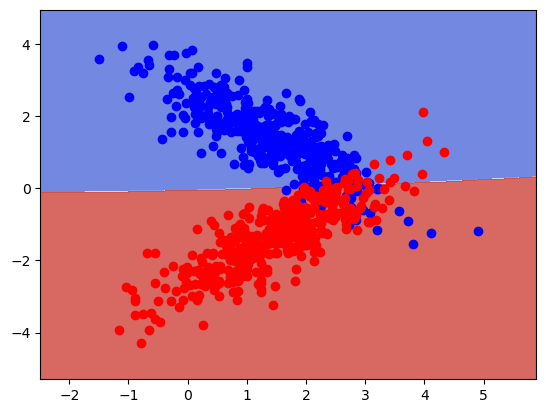

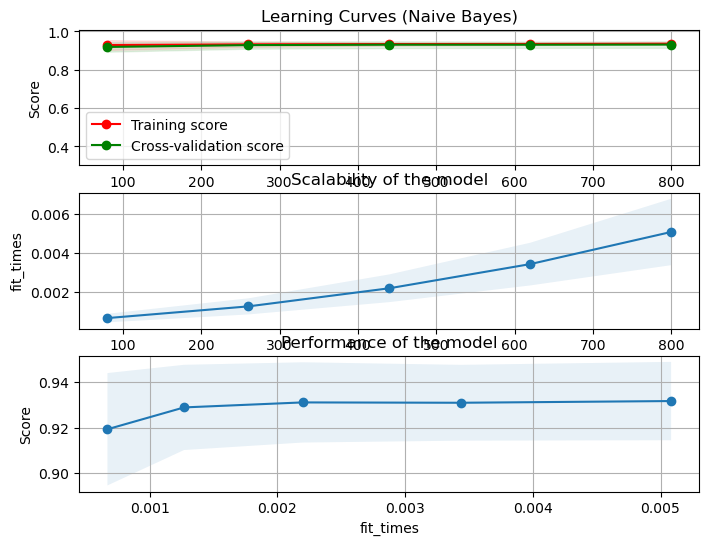

In [ ]:
#variar la cantida de datos


rv, rv1 = data( mu=[1.4,1.4], mu1=[1.4,-1.4],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 500, N2 = 500, r = 10)


X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size = 0.2,
                                                    random_state=1)
clf = SVC(gamma = 0.01)
clf.fit(X_train, y_train)
fig, ax = plt.subplots()
X0, X1 = X_train[:, 0], X_train[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train[y_train==0][:,0],X_train[y_train==0][:,1],"bo", alpha=1)
plt.plot(X_train[y_train==1][:,0],X_train[y_train==1][:,1],"ro", alpha=1)
print(f"Training error:{clf.score(X_train, y_train):.3f}")
print(f"Test error: {clf.score(X_test, y_test):.3f}" )

fig, axes = plt.subplots(3, 1, figsize=(8, 6))
title = "Learning Curves (Naive Bayes)"
# Cross validation with 100 iterations to get smoother mean test and train
# score curves, each time with 20% data randomly selected as a validation set.
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)
#clf = SVC(gamma = 20.0)
#clf.fit(X_t, y)
plot_learning_curve(clf, title, X_t, y, axes=axes, ylim=(0.3, 1.01), cv=cv, n_jobs=4)
plt.show()

# Underfiting

Training error:0.875
Test error: 0.786


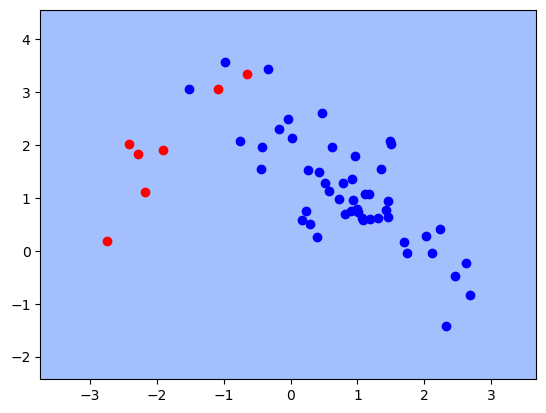

In [ ]:
rv, rv1 = data( mu=[1,1], mu1=[-2,2],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.5], [0.5, 1.0]])

X_t, y = sample(N1 = 60, N2 = 10, r = 10)

X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size = 0.2,
                                                    random_state=1)
clf = SVC(gamma = 0.001)
clf.fit(X_train, y_train)
fig, ax = plt.subplots()
X0, X1 = X_train[:, 0], X_train[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train[y_train==0][:,0],X_train[y_train==0][:,1],"bo", alpha=1)
plt.plot(X_train[y_train==1][:,0],X_train[y_train==1][:,1],"ro", alpha=1)
print(f"Training error:{clf.score(X_train, y_train):.3f}")
print(f"Test error: {clf.score(X_test, y_test):.3f}" )


<!-- # Selección de Modelos y Conjuntos de Entrenamiento/Validación/Prueba
[1] Referencia: https://cs229.stanford.edu/

El hecho de que un algoritmo de aprendizaje ajuste bien un conjunto de entrenamiento no significa que sea una buena hipótesis. Podría sobreajustarse, lo que resultaría en predicciones deficientes en el conjunto de prueba. El error de tu hipótesis, medido en el conjunto de datos con el que entrenaste los parámetros, será menor que el error en cualquier otro conjunto de datos.

Dado que tenemos muchos modelos con diferentes grados polinomiales, podemos usar un enfoque sistemático para identificar la 'mejor' función. Para elegir el modelo de tu hipótesis, puedes probar cada grado del polinomio y observar el resultado del error.

Una forma de dividir nuestro conjunto de datos en tres conjuntos es la siguiente:

- **Conjunto de entrenamiento**: 60%
- **Conjunto de validación cruzada**: 20%
- **Conjunto de prueba**: 20%

Ahora podemos calcular tres valores de error separados para los tres conjuntos diferentes utilizando el siguiente método:

1. Optimiza los parámetros en \( \Theta \) utilizando el conjunto de entrenamiento para cada grado polinomial.

2. Encuentra el grado polinomial \( d \) con el menor error utilizando el conjunto de validación cruzada.

3. Estima el error de generalización utilizando el conjunto de prueba con \( J_{\text{test}} \).

De esta manera, el grado del polinomio \( d \) no ha sido entrenado utilizando el conjunto de prueba. -->


<!--
Tarea :

3.1 Para esta situación tomar el 20% como datos para realizar la validacion cruzada y el 80% paara realizar el entrenamiento. Construir una curva del score en función del parametro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solucion al problema?.  

3.2 Construir las curvas de aprendizaje  para el modelo descrito, comprobar que la solución es similar a la esperada a través de sklean.

3.3 Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar Mostrar un ejemplo de Overfitting underfitting con el algoritmo generados construido por ustedes.  Analizar los resultados.
 -->


In [ ]:
# Como se construye una curva de aprendizaje?
#import from sklearn.model_selection import ShuffleSplit
#from sklearn import cross_validation

# Notebook con solucion a la tarea
rv, rv1 = data( mu=[1.2,1.4], mu1=[1.4,-1.4],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 100, N2 = 100, r = 10)

g=10

#size = np.linspace(0.1, 0.95, 9)
train_score_=[]
test_score_=[]
Strain_score_=[]
Stest_score_=[]
size = np.arange(40, 160, 20)
for s in size:
  a=[]
  b=[]
  for exec in range(0, 10):
    X_train, X_test, y_train, y_test = train_test_split(X_t, y,
                                                        test_size = 0.3)
    arr = np.arange(s)
    index = np.random.permutation(arr)

    clf = SVC(gamma = g)
    clf.fit(X_train[:][index], y_train[index])
    train_score = clf.score(X_train[:][index], y_train[index])

    arr = np.arange(len(y_test))
    index_test =  np.random.permutation(arr)
    test_score = clf.score(X_test[:][index_test], y_test[index_test])

    a.append(train_score)
    b.append(test_score)

  train_score_.append(np.mean(a))
  test_score_.append(np.mean(b))
  Strain_score_.append(np.std(a))
  Stest_score_.append(np.std(b))

train_mean = np.array(train_score_)
test_mean = np.array(test_score_)
train_std = np.array(Strain_score_)
test_std = np.array(Stest_score_)


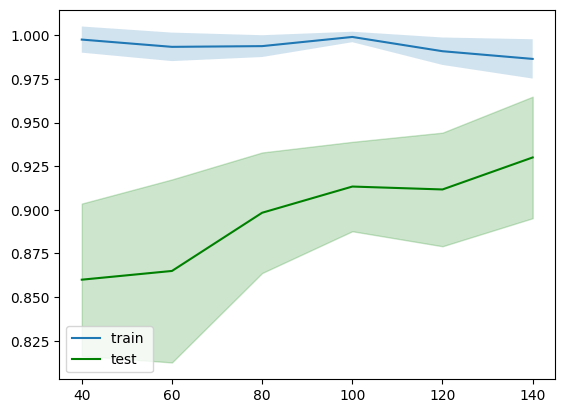

In [ ]:
plt.plot(size, train_mean, label = "train ")
plt.fill_between(size, train_mean-train_std, train_mean+train_std, alpha=0.2)

plt.plot(size, test_mean,"g-" ,label = "test")
plt.fill_between(size, test_mean-test_std, test_mean+test_std,color="g",alpha=0.2)
plt.legend()
#plt.ylim(0.8, 1.1)

Training error:0.975
Test error: 0.925


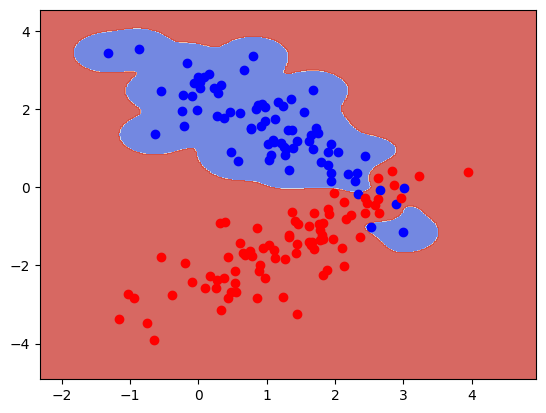

In [ ]:
# Como se hace un make contour
rv, rv1 = data( mu=[1.2,1.4], mu1=[1.4,-1.4],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 100, N2 = 100, r = 10)

X_t, y = sample(N1 = 100, N2 = 100, r = 10)

X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size = 0.2,
                                                    random_state=1)
clf = SVC(gamma = g)
clf.fit(X_train, y_train)
fig, ax = plt.subplots()
X0, X1 = X_train[:, 0], X_train[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
plt.plot(X_train[y_train==0][:,0],X_train[y_train==0][:,1],"bo", alpha=1)
plt.plot(X_train[y_train==1][:,0],X_train[y_train==1][:,1],"ro", alpha=1)
print(f"Training error:{clf.score(X_train, y_train):.3f}")
print(f"Test error: {clf.score(X_test, y_test):.3f}" )